# Notebook Overview — Extract Spatial Features

## Purpose

This notebook extracts **spatial-domain features** from preprocessed images for a selected dataset subset (**train** or **test**).

It computes entropy-based, intensity-based, texture-based, and noise-based features, and outputs structured feature vectors for downstream classification.

---

## Inputs

Required inputs:

* Metadata CSV file (train or test):
  * `metadata/splits/<train_metadata_filename>`
  * `metadata/splits/<test_metadata_filename>`

* Preprocessed image archive:
  * `releases/preprocessed/All_Sources_preprocessed.zip`

Shared configuration:

* `src/project_config.py`

---

## Execution Model

* One subset (**train** or **test**) is processed per run
* Metadata is loaded and validated for consistency
* Image file paths are constructed and verified
* Preprocessed images are extracted to the local runtime if needed
* Spatial features are computed using entropy, intensity, and texture measures
* Feature extraction is performed sequentially across all images
* Errors during processing are handled and reported
* Output feature vectors are validated and saved to CSV
* Processing is deterministic and reproducible

---

## Outputs

**Spatial Feature CSV (Train)**  
`metadata/features/<train_spatial_features_filename>`

**Spatial Feature CSV (Test)**  
`metadata/features/<test_spatial_features_filename>`

Each output file contains:

* Metadata columns:
  * `filename`
  * `class_label`
  * `source_dataset`
  * `subset`

* Spatial feature columns:
  * Global Entropy  
  * Local Entropy Mean  
  * Local Entropy Std  
  * Intensity Mean  
  * Intensity Std  
  * Laplacian Variance  
  * Patch Variance Mean  
  * Patch Variance Std  
  * Noise Residual Energy  

**Expected Behavior**

* One feature vector is generated per input image  
* Output row count matches input metadata (unless errors occur)  
* Feature values are computed consistently across all images  
* Output is ready for downstream feature combination and normalization  

---
---

### 🔷 Step 1 — Startup: Environment and Verification

- Mount Google Drive for access to the preprocessed image ZIP archive
- Clone the GitHub repository if needed
- Add the project `src` directory to the Python path
- Import shared configuration values from `project_config.py`
- Define metadata, image extraction, and spatial feature output paths
- Select the train or test subset for feature extraction
- Verify that required metadata and ZIP input files are present
- Extract preprocessed images into the local runtime if needed
- Verify that extracted PNG images are available
- Optionally display key configuration values when `VERBOSE=True`

---

In [1]:
# ============================================
# Step 1: Startup — Environment and Verification
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import os
import sys
import zipfile
from pathlib import Path

# -------------------------------------------------
# Notebook display control
# -------------------------------------------------
VERBOSE = True   # Set to False to reduce detailed output

# -------------------------------------------------
# Mount Google Drive for access to release ZIP archive
# -------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

# -------------------------------------------------
# Clone GitHub repository if needed
# -------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# -------------------------------------------------
# Add src directory to Python path
# -------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# -------------------------------------------------
# Import shared project configuration
# -------------------------------------------------
from project_config import (
    TRAIN_SUBSET,
    TEST_SUBSET,
    TRAIN_METADATA_PATH,
    TEST_METADATA_PATH,
    TRAIN_SPATIAL_FEATURES_PATH,
    TEST_SPATIAL_FEATURES_PATH,
    PREPROCESSED_ZIP_PATHS,
    PROCESSED_DATA_DIR,
    FEATURES_METADATA_DIR,
)

# -------------------------------------------------
# Convert configured paths to Path objects
# -------------------------------------------------
TRAIN_METADATA_FILE = Path(TRAIN_METADATA_PATH)
TEST_METADATA_FILE = Path(TEST_METADATA_PATH)

TRAIN_OUTPUT_FILE = Path(TRAIN_SPATIAL_FEATURES_PATH)
TEST_OUTPUT_FILE = Path(TEST_SPATIAL_FEATURES_PATH)

PREPROCESSED_ZIP = Path(PREPROCESSED_ZIP_PATHS["all_sources"])

EXTRACTED_IMAGE_DIR = Path(PROCESSED_DATA_DIR) / "images"
FEATURES_DIR = Path(FEATURES_METADATA_DIR)

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
EXTRACTED_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Select subset to process
# -------------------------------------------------
SUBSET_NAME = TRAIN_SUBSET   # Either TRAIN_SUBSET or TEST_SUBSET

if SUBSET_NAME == TRAIN_SUBSET:
    METADATA_FILE = TRAIN_METADATA_FILE
    OUTPUT_FILE = TRAIN_OUTPUT_FILE
elif SUBSET_NAME == TEST_SUBSET:
    METADATA_FILE = TEST_METADATA_FILE
    OUTPUT_FILE = TEST_OUTPUT_FILE
else:
    raise ValueError(f"Invalid SUBSET_NAME: {SUBSET_NAME}")

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("Verifying required inputs...\n")

required_files = [
    METADATA_FILE,
    PREPROCESSED_ZIP,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required file: {file_path}")

print("Required input files are present.")

# -------------------------------------------------
# Optional verbose display of configuration values
# -------------------------------------------------
if VERBOSE:
    print(f"Subset selected:  {SUBSET_NAME}")
    print(f"Metadata file:    {METADATA_FILE}")
    print(f"Preprocessed ZIP: {PREPROCESSED_ZIP}")
    print(f"Extracted images: {EXTRACTED_IMAGE_DIR}")
    print(f"Output file:      {OUTPUT_FILE}")

# -------------------------------------------------
# Extract preprocessed image ZIP if needed
# -------------------------------------------------
existing_png_count = len(list(EXTRACTED_IMAGE_DIR.glob("*.png")))

if existing_png_count > 0:
    print(f"\nExtracted image directory already contains {existing_png_count} PNG files.")
    print("Skipping extraction.")
else:
    print("\nExtracting All_Sources_preprocessed.zip to local runtime...")
    with zipfile.ZipFile(PREPROCESSED_ZIP, "r") as zip_ref:
        zip_ref.extractall(EXTRACTED_IMAGE_DIR)
    print("Extraction complete.")

# -------------------------------------------------
# Verify extracted image files
# -------------------------------------------------
image_files = list(EXTRACTED_IMAGE_DIR.glob("*.png"))

if len(image_files) == 0:
    raise FileNotFoundError(
        f"No PNG files found in extracted image directory: {EXTRACTED_IMAGE_DIR}"
    )

print(f"Found {len(image_files)} extracted PNG files.")
print("\nStartup complete.")



Mounted at /content/drive
Cloning repository...
Verifying required inputs...

Required input files are present.
Subset selected:  train
Metadata file:    /content/dip-ai-image-detection/metadata/splits/train_metadata.csv
Preprocessed ZIP: /content/drive/MyDrive/DIP_Project/releases/preprocessed/All_Sources_preprocessed.zip
Extracted images: /content/dip-ai-image-detection/data/preprocessed/images
Output file:      /content/dip-ai-image-detection/metadata/features/train_spatial_features.csv

Extracting All_Sources_preprocessed.zip to local runtime...
Extraction complete.
Found 18000 extracted PNG files.

Startup complete.


### 🔷 Step 2 — Load Metadata

- Load the selected train or test metadata CSV file
- Verify that required metadata columns are present
- Confirm that the metadata subset matches the selected subset
- Build local image paths from metadata filenames
- Verify that all metadata-referenced image files exist
- Optionally display class/source distributions and sample rows when `VERBOSE=True`

---

In [2]:
# ============================================
# Step 2: Load Metadata
# ============================================

# -------------------------------------------------
# Import required library
# -------------------------------------------------
import pandas as pd

# -------------------------------------------------
# Load selected subset metadata
# -------------------------------------------------
df = pd.read_csv(METADATA_FILE)

print(f"Loaded metadata for subset: {SUBSET_NAME}")
print(f"Metadata shape: {df.shape}")

# -------------------------------------------------
# Verify required metadata columns
# -------------------------------------------------
required_columns = ["filename", "class_label", "source_dataset", "subset"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Metadata file is missing required columns: {missing_columns}")

print("Required metadata columns verified.")

# -------------------------------------------------
# Verify subset consistency
# -------------------------------------------------
unique_subsets = sorted(df["subset"].dropna().unique().tolist())

if unique_subsets != [SUBSET_NAME]:
    raise ValueError(
        f"Metadata subset mismatch. Expected only '{SUBSET_NAME}', found: {unique_subsets}"
    )

if VERBOSE:
    print(f"Subset column verified: {unique_subsets}")

# -------------------------------------------------
# Build image paths from filenames
# -------------------------------------------------
df["image_path"] = df["filename"].apply(lambda x: EXTRACTED_IMAGE_DIR / x)

# -------------------------------------------------
# Verify metadata-referenced image files
# -------------------------------------------------
missing_images = df.loc[~df["image_path"].apply(lambda p: p.exists()), "filename"].tolist()

if missing_images:
    raise FileNotFoundError(
        "Some image files referenced by metadata were not found in the extracted image directory.\n"
        f"First missing files: {missing_images[:10]}"
    )

print("All metadata-referenced image files were found.")

# -------------------------------------------------
# Optional verbose display of metadata summary
# -------------------------------------------------
if VERBOSE:
    print("\nClass distribution:")
    print(df["class_label"].value_counts())

if VERBOSE:
    print("\nSource distribution:")
    print(df["source_dataset"].value_counts())

    print("\nSample rows:")
    display(df.head())



Loaded metadata for subset: train
Metadata shape: (14400, 4)
Required metadata columns verified.
Subset column verified: ['train']
All metadata-referenced image files were found.

Class distribution:
class_label
rl    7200
ai    7200
Name: count, dtype: int64

Source distribution:
source_dataset
ImageNet_1K_256       2400
MS_COCO_2017          2400
Midjourney            2400
OpenImages            2400
SDXL_Generated_10K    2400
DiffusionDB           2400
Name: count, dtype: int64

Sample rows:


,filename,source_dataset,class_label,subset,image_path
0,rl_imgn_002320.png,ImageNet_1K_256,rl,train,/content/dip-ai-image-detection/data/preproces...
1,rl_coco_001397.png,MS_COCO_2017,rl,train,/content/dip-ai-image-detection/data/preproces...
2,rl_imgn_001958.png,ImageNet_1K_256,rl,train,/content/dip-ai-image-detection/data/preproces...
3,rl_coco_000800.png,MS_COCO_2017,rl,train,/content/dip-ai-image-detection/data/preproces...
4,ai_mj_002892.png,Midjourney,ai,train,/content/dip-ai-image-detection/data/preproces...


### 🔷 Step 3 — Spatial Feature Helper Functions

- Define helper function for stable entropy computation from histograms
- Define global image entropy computation
- Define local entropy computation using quantized image and disk neighborhood
- Define Laplacian-based texture computation
- Define patch-level variance statistics
- Define noise residual computation
- Define spatial feature extraction function
- Compute entropy, intensity, texture, and noise-based features

---

In [3]:
# ============================================
# Step 3: Spatial Feature Helper Functions
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import numpy as np
import cv2
from scipy.stats import entropy
from skimage.filters.rank import entropy as local_entropy
from skimage.morphology import disk

# -------------------------------------------------
# Helper: entropy from histogram
# -------------------------------------------------
def safe_entropy_from_hist(hist, eps=1e-12):
    # Normalize histogram and compute entropy
    hist = hist.astype(np.float64)
    hist = hist / (hist.sum() + eps)
    hist = np.clip(hist, eps, None)
    return float(entropy(hist, base=2))

# -------------------------------------------------
# Global image entropy
# -------------------------------------------------
def image_hist_entropy(img, bins=256):
    # Compute entropy of full image intensity distribution
    hist, _ = np.histogram(img.ravel(), bins=bins, range=(0, 255))
    return safe_entropy_from_hist(hist)

# -------------------------------------------------
# Local entropy map
# -------------------------------------------------
def compute_local_entropy(img, window_size=9):
    # Quantize image and compute local entropy using disk neighborhood
    img_uint8 = img.astype(np.uint8)
    img_q = (img_uint8 // 8).astype(np.uint8)   # 32-level quantization

    local_entropy_map = local_entropy(
        img_q,
        disk(window_size // 2)
    ).astype(np.float32)

    return local_entropy_map

# -------------------------------------------------
# Laplacian response
# -------------------------------------------------
def compute_laplacian(img):
    # Compute Laplacian response of image
    return cv2.Laplacian(img, cv2.CV_32F)

# -------------------------------------------------
# Patch variance statistics
# -------------------------------------------------
def patch_variance_stats(img, patch_size=16):
    # Compute mean and standard deviation of patch-level variances
    h, w = img.shape
    h_crop = (h // patch_size) * patch_size
    w_crop = (w // patch_size) * patch_size

    img_c = img[:h_crop, :w_crop]

    patches = img_c.reshape(
        h_crop // patch_size, patch_size,
        w_crop // patch_size, patch_size
    ).transpose(0, 2, 1, 3)

    patch_vars = patches.reshape(-1, patch_size, patch_size).var(axis=(1, 2))

    return float(patch_vars.mean()), float(patch_vars.std())

# -------------------------------------------------
# Noise residual
# -------------------------------------------------
def compute_noise_residual(img):
    # Compute residual between image and Gaussian-blurred version
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    residual = img.astype(np.float32) - blurred.astype(np.float32)
    return residual

# -------------------------------------------------
# Extract spatial features
# -------------------------------------------------
def extract_spatial_features(img):
    # Global entropy
    global_entropy = image_hist_entropy(img)

    # Local entropy statistics
    local_entropy_map = compute_local_entropy(img)
    local_entropy_mean = float(np.mean(local_entropy_map))
    local_entropy_std = float(np.std(local_entropy_map))

    # Intensity statistics
    intensity_mean = float(np.mean(img))
    intensity_std = float(np.std(img))

    # Laplacian-based texture measure
    lap = compute_laplacian(img)
    laplacian_variance = float(np.var(lap))

    # Patch-level variance statistics
    patch_var_mean, patch_var_std = patch_variance_stats(img)

    # Noise residual energy
    residual = compute_noise_residual(img)
    noise_residual_energy = float(np.mean(residual ** 2))

    # Assemble feature vector
    features = {
        "Global Entropy": global_entropy,
        "Local Entropy Mean": local_entropy_mean,
        "Local Entropy Std": local_entropy_std,
        "Intensity Mean": intensity_mean,
        "Intensity Std": intensity_std,
        "Laplacian Variance": laplacian_variance,
        "Patch Variance Mean": patch_var_mean,
        "Patch Variance Std": patch_var_std,
        "Noise Residual Energy": noise_residual_energy,
    }

    return features, local_entropy_map, lap, residual

print("Spatial helper functions defined.")



Spatial helper functions defined.


### 🔷 Step 4 — Preview and Validate Sample Image

- Select a sample image from the loaded metadata
- Verify that the image file exists and can be loaded
- Confirm expected image format (grayscale, 256×256)
- Compute spatial features for the sample image
- Optionally display sample metadata and feature values when `VERBOSE=True`
- Visualize the image, local entropy map, Laplacian response, and noise residual

---

Sample metadata row:
filename: rl_imgn_002320.png
source_dataset: ImageNet_1K_256
class_label: rl
subset: train
image_path: /content/dip-ai-image-detection/data/preprocessed/images/rl_imgn_002320.png

Sample image path: /content/dip-ai-image-detection/data/preprocessed/images/rl_imgn_002320.png
Loaded sample image shape: (256, 256)
Loaded sample image dtype: uint8
Sample image format verified.

Sample spatial features:
Global Entropy: 7.730578
Local Entropy Mean: 2.481306
Local Entropy Std: 1.245892
Intensity Mean: 131.919647
Intensity Std: 72.487973
Laplacian Variance: 4362.239258
Patch Variance Mean: 1817.941326
Patch Variance Std: 1845.180777
Noise Residual Energy: 308.872894

Number of features extracted: 9


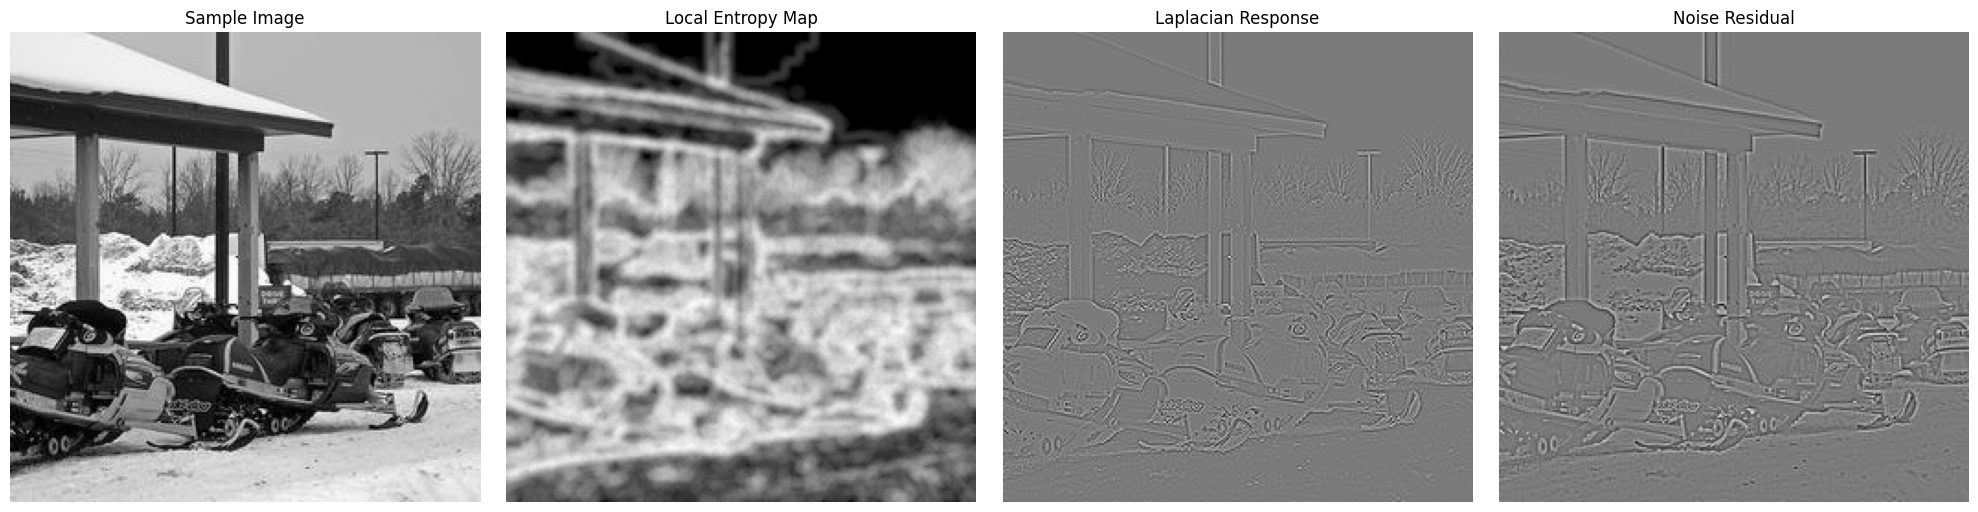

In [4]:
# ============================================
# Step 4: Preview and Validate Sample Image
# ============================================

# -------------------------------------------------
# Import required library
# -------------------------------------------------
import matplotlib.pyplot as plt

# -------------------------------------------------
# Select a sample image from metadata
# -------------------------------------------------
sample_row = df.iloc[0]
sample_path = sample_row["image_path"]

# -------------------------------------------------
# Optional verbose display of sample metadata
# -------------------------------------------------
if VERBOSE:
    print("Sample metadata row:")
    for key, value in sample_row.items():
        print(f"{key}: {value}")

    print(f"\nSample image path: {sample_path}")

if not sample_path.exists():
    raise FileNotFoundError(f"Sample image not found: {sample_path}")

# -------------------------------------------------
# Load sample image in grayscale
# -------------------------------------------------
sample_img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

if sample_img is None:
    raise ValueError(f"Could not load sample image: {sample_path}")

# -------------------------------------------------
# Verify image properties
# -------------------------------------------------
if VERBOSE:
    print(f"Loaded sample image shape: {sample_img.shape}")
    print(f"Loaded sample image dtype: {sample_img.dtype}")

if len(sample_img.shape) != 2:
    raise ValueError("Expected grayscale image with 2 dimensions.")

if sample_img.shape != (256, 256):
    raise ValueError(f"Expected image shape (256, 256), found {sample_img.shape}")

print("Sample image format verified.")

# -------------------------------------------------
# Compute spatial features for sample image
# -------------------------------------------------
sample_features, local_entropy_map, lap, residual = extract_spatial_features(sample_img)

# -------------------------------------------------
# Optional verbose display of sample features
# -------------------------------------------------
if VERBOSE:
    print("\nSample spatial features:")
    for key, value in sample_features.items():
        print(f"{key}: {value:.6f}")

    print(f"\nNumber of features extracted: {len(sample_features)}")

# -------------------------------------------------
# Display sample image and spatial visualizations
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Sample Image")
axes[0].axis("off")

axes[1].imshow(local_entropy_map, cmap="gray")
axes[1].set_title("Local Entropy Map")
axes[1].axis("off")

axes[2].imshow(lap, cmap="gray")
axes[2].set_title("Laplacian Response")
axes[2].axis("off")

axes[3].imshow(residual, cmap="gray")
axes[3].set_title("Noise Residual")
axes[3].axis("off")

plt.tight_layout()
plt.show()



### 🔷 Step 5 — Extract Spatial Features for Subset

- Iterate over all images in the selected subset
- Load each image in grayscale format
- Compute spatial feature vectors for each image
- Assemble metadata and feature values into structured records
- Handle and track errors for failed image processing
- Convert extracted records into a DataFrame
- Verify expected output columns and ordering
- Report extraction summary and processing statistics
- Optionally display sample output rows when `VERBOSE=True`

---

In [5]:
# ============================================
# Step 5: Extract Spatial Features for Subset
# ============================================

# -------------------------------------------------
# Import progress tracking utility
# -------------------------------------------------
from tqdm.notebook import tqdm

# -------------------------------------------------
# Extract features for all images in selected subset
# -------------------------------------------------
records = []
error_count = 0

print(f"Beginning spatial feature extraction for subset: {SUBSET_NAME}")
print(f"Total images to process: {len(df)}\n")

for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {SUBSET_NAME} images"):
    image_path = row["image_path"]

    try:
        # Load image in grayscale
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        # Extract spatial features
        features, _, _, _ = extract_spatial_features(img)

        # Build output record
        record = {
            "filename": row["filename"],
            "class_label": row["class_label"],
            "source_dataset": row["source_dataset"],
            "subset": row["subset"],
        }
        record.update(features)
        records.append(record)

    except Exception as e:
        error_count += 1
        if VERBOSE:
            print(f"Skipping {row['filename']} due to error: {e}")

# -------------------------------------------------
# Convert records to DataFrame
# -------------------------------------------------
spatial_features_df = pd.DataFrame(records)

# -------------------------------------------------
# Verify output structure and column order
# -------------------------------------------------
expected_columns = [
    "filename",
    "class_label",
    "source_dataset",
    "subset",
    "Global Entropy",
    "Local Entropy Mean",
    "Local Entropy Std",
    "Intensity Mean",
    "Intensity Std",
    "Laplacian Variance",
    "Patch Variance Mean",
    "Patch Variance Std",
    "Noise Residual Energy",
]

missing_columns = [col for col in expected_columns if col not in spatial_features_df.columns]
if missing_columns:
    raise ValueError(f"Missing expected output columns: {missing_columns}")

spatial_features_df = spatial_features_df[expected_columns]

# -------------------------------------------------
# Summary of extraction results
# -------------------------------------------------
print("\nSpatial feature extraction complete.")
print(f"Output shape: {spatial_features_df.shape}")
print(f"Processed images: {len(spatial_features_df)}")
print(f"Expected images:  {len(df)}")

if error_count > 0:
    print(f"Skipped images:   {error_count}")

if len(spatial_features_df) != len(df):
    print("\nWARNING: Some images were skipped during processing.")

# -------------------------------------------------
# Optional verbose display of output sample
# -------------------------------------------------
if VERBOSE:
    print("\nSample output rows:")
    display(spatial_features_df.head())



Beginning spatial feature extraction for subset: train
Total images to process: 14400



Processing train images:   0%|          | 0/14400 [00:00<?, ?it/s]


Spatial feature extraction complete.
Output shape: (14400, 13)
Processed images: 14400
Expected images:  14400

Sample output rows:


,filename,class_label,source_dataset,subset,Global Entropy,Local Entropy Mean,Local Entropy Std,Intensity Mean,Intensity Std,Laplacian Variance,Patch Variance Mean,Patch Variance Std,Noise Residual Energy
0,rl_imgn_002320.png,rl,ImageNet_1K_256,train,7.730578,2.481306,1.245892,131.919647,72.487973,4362.239258,1817.941326,1845.180777,308.872894
1,rl_coco_001397.png,rl,MS_COCO_2017,train,7.022424,1.768247,1.010870,59.396927,52.390971,970.609985,798.407524,1525.370321,81.501587
2,rl_imgn_001958.png,rl,ImageNet_1K_256,train,7.350558,2.544127,0.993669,106.468567,51.111137,3632.192871,1274.883664,1353.469364,246.181076
3,rl_coco_000800.png,rl,MS_COCO_2017,train,7.337275,1.882246,1.239108,171.240051,63.686768,2166.902100,1115.830063,1453.744813,161.045258
4,ai_mj_002892.png,ai,Midjourney,train,7.745233,2.287869,0.791415,117.655350,59.277463,589.124878,823.514669,971.494479,50.079971


### 🔷 Step 6 — Save Output

- Create output directory if it does not exist
- Save spatial feature DataFrame to CSV file
- Confirm output file location
- Verify that the output file was created successfully
- Validate that saved row count matches extracted data

---

In [6]:
# ============================================
# Step 6: Save Output
# ============================================

# -------------------------------------------------
# Ensure output directory exists
# -------------------------------------------------
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Save spatial feature DataFrame to CSV
# -------------------------------------------------
spatial_features_df.to_csv(OUTPUT_FILE, index=False)

# -------------------------------------------------
# Confirm save location
# -------------------------------------------------
print(f"Saved spatial features to: {OUTPUT_FILE}")

# -------------------------------------------------
# Verify output file was created
# -------------------------------------------------
if not OUTPUT_FILE.exists():
    raise FileNotFoundError(f"Output file was not created: {OUTPUT_FILE}")

# -------------------------------------------------
# Verify saved row count
# -------------------------------------------------
saved_df = pd.read_csv(OUTPUT_FILE)

if len(saved_df) != len(spatial_features_df):
    raise ValueError(
        f"Saved row count mismatch. Expected {len(spatial_features_df)}, found {len(saved_df)}"
    )

print(f"Verified saved file row count: {len(saved_df)}")



Saved spatial features to: /content/dip-ai-image-detection/metadata/features/train_spatial_features.csv
Verified saved file row count: 14400


### 🔷 Step 7 — Final Summary and Next Step

- Display summary of spatial feature extraction results
- Report input size, output size, and saved file location
- List extracted spatial feature columns
- Provide guidance for next execution step (train → test)
- Display formatted completion message

---

In [7]:
# ============================================
# Step 7: Final Summary and Next Step
# ============================================

# -------------------------------------------------
# Import display utilities
# -------------------------------------------------
from IPython.display import display, HTML

# -------------------------------------------------
# Print execution summary
# -------------------------------------------------
print("Spatial feature extraction completed successfully.\n")

print(f"Subset processed : {SUBSET_NAME}")
print(f"Input rows       : {len(df)}")
print(f"Output rows      : {len(spatial_features_df)}")
print(f"Output columns   : {len(spatial_features_df.columns)}")
print(f"Saved file       : {OUTPUT_FILE}")

# -------------------------------------------------
# Display feature column names
# -------------------------------------------------
print("\nFeature columns:")
for col in spatial_features_df.columns[4:]:
    print(f"  - {col}")

# -------------------------------------------------
# Display next-step guidance message
# -------------------------------------------------
if SUBSET_NAME == TRAIN_SUBSET:
    message = """
    <b>Next Step:</b><br>
    Set <code>SUBSET_NAME = TEST_SUBSET</code> in Step 1 and rerun this notebook to generate <b>test</b> spatial features.
    """
    border_color = "#ff9800"
    bg_color = "#fff3e0"
else:
    message = f"""
    <b>Current Run Complete:</b><br>
    This run generated <b>{OUTPUT_FILE.name}</b> for the <b>test</b> subset.<br>
    Notebook completed.
    """
    border_color = "#4CAF50"
    bg_color = "#E8F5E9"

# -------------------------------------------------
# Render formatted summary message
# -------------------------------------------------
display(HTML(f"""
<div style="
    padding: 15px;
    border: 2px solid {border_color};
    background-color: {bg_color};
    border-radius: 8px;
    font-size: 16px;
">
{message}
</div>
"""))



Spatial feature extraction completed successfully.

Subset processed : train
Input rows       : 14400
Output rows      : 14400
Output columns   : 13
Saved file       : /content/dip-ai-image-detection/metadata/features/train_spatial_features.csv

Feature columns:
  - Global Entropy
  - Local Entropy Mean
  - Local Entropy Std
  - Intensity Mean
  - Intensity Std
  - Laplacian Variance
  - Patch Variance Mean
  - Patch Variance Std
  - Noise Residual Energy
